# K-Means and K-Medoids Clustering Study

This notebook adds a supplementary clustering comparison without changing the main clustering pipeline.

Workflow:
- reuse saved classifier embedding artifacts from `models/clustering`
- retain the existing K-Means baseline
- add a K-Medoids variant using a CLARA-style sampled PAM refinement
- save comparison metrics back into `models/clustering` for the dashboard

Run the standard clustering pipeline first so that `embeddings_pca.npy`, `labels.npy`, and `tsne_idx.npy` already exist.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, normalized_mutual_info_score, silhouette_score

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CLUSTER_DIR = PROJECT_ROOT / "models" / "clustering"
GRAPHS_DIR = CLUSTER_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

emb_pca = np.load(CLUSTER_DIR / "embeddings_pca.npy")
labels = np.load(CLUSTER_DIR / "labels.npy")
tsne_idx = np.load(CLUSTER_DIR / "tsne_idx.npy") if (CLUSTER_DIR / "tsne_idx.npy").exists() else None
n_clusters = int(json.loads((CLUSTER_DIR / "clustering_metrics.json").read_text(encoding="utf-8")).get("n_clusters", 3))
class_names = sorted([p.name for p in (PROJECT_ROOT / "data" / "train").iterdir() if p.is_dir()])
emb_pca.shape, labels.shape

((27560, 1464), (27560,))

In [3]:
def pairwise_distances(x: np.ndarray) -> np.ndarray:
    sq = np.sum(x ** 2, axis=1, keepdims=True)
    dist2 = np.maximum(sq + sq.T - 2 * x @ x.T, 0.0)
    return np.sqrt(dist2)

def assign_from_medoids(points: np.ndarray, medoid_vectors: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    distances = np.linalg.norm(points[:, None, :] - medoid_vectors[None, :, :], axis=2)
    labels_pred = distances.argmin(axis=1)
    return labels_pred, distances

def initialize_medoids(sample_points: np.ndarray, k: int, seed: int = 42) -> list[int]:
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    km.fit(sample_points)
    medoids = []
    for center in km.cluster_centers_:
        idx = int(np.argmin(np.linalg.norm(sample_points - center, axis=1)))
        if idx not in medoids:
            medoids.append(idx)
    rng = np.random.default_rng(seed)
    while len(medoids) < k:
        candidate = int(rng.integers(0, len(sample_points)))
        if candidate not in medoids:
            medoids.append(candidate)
    return medoids

def pam_refine(sample_points: np.ndarray, k: int, max_iter: int = 12, seed: int = 42) -> list[int]:
    dist = pairwise_distances(sample_points)
    medoids = initialize_medoids(sample_points, k, seed=seed)

    def cost(current_medoids: list[int]) -> float:
        return float(np.min(dist[:, current_medoids], axis=1).sum())

    current_cost = cost(medoids)
    for _ in range(max_iter):
        improved = False
        non_medoids = [idx for idx in range(len(sample_points)) if idx not in medoids]
        for pos, current_medoid in enumerate(list(medoids)):
            best_candidate = None
            best_cost = current_cost
            for candidate in non_medoids:
                trial = medoids.copy()
                trial[pos] = candidate
                trial_cost = cost(trial)
                if trial_cost < best_cost - 1e-6:
                    best_cost = trial_cost
                    best_candidate = candidate
            if best_candidate is not None:
                medoids[pos] = best_candidate
                current_cost = best_cost
                improved = True
                break
        if not improved:
            break
    return medoids

def build_metrics(points: np.ndarray, true_labels: np.ndarray, pred_labels: np.ndarray, k: int) -> dict:
    return {
        "n_clusters": int(k),
        "total_samples": int(len(true_labels)),
        "silhouette_score": float(silhouette_score(points, pred_labels, sample_size=min(2000, len(points)))),
        "davies_bouldin_index": float(davies_bouldin_score(points, pred_labels)),
        "calinski_harabasz_index": float(calinski_harabasz_score(points, pred_labels)),
        "adjusted_rand_index": float(adjusted_rand_score(true_labels, pred_labels)),
        "normalized_mutual_info": float(normalized_mutual_info_score(true_labels, pred_labels)),
        "cluster_sizes": {str(i): int((pred_labels == i).sum()) for i in range(k)},
    }

sample_size = min(1200, len(emb_pca))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(emb_pca), size=sample_size, replace=False)
sample_points = emb_pca[sample_idx]

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(emb_pca)
kmeans_metrics = build_metrics(emb_pca, labels, kmeans_labels, n_clusters)

sample_medoids = pam_refine(sample_points, n_clusters, max_iter=10, seed=42)
global_medoid_indices = sample_idx[sample_medoids]
medoid_vectors = emb_pca[global_medoid_indices]
kmedoids_labels, _ = assign_from_medoids(emb_pca, medoid_vectors)
kmedoids_metrics = build_metrics(emb_pca, labels, kmedoids_labels, n_clusters)

comparison = {
    "feature_space": "embeddings_pca.npy",
    "kmeans": kmeans_metrics,
    "kmedoids": {**kmedoids_metrics, "medoid_indices": global_medoid_indices.tolist()},
}

np.save(CLUSTER_DIR / "kmedoids_cluster_labels.npy", kmedoids_labels)
if tsne_idx is not None:
    np.save(CLUSTER_DIR / "kmedoids_tsne_clusters.npy", kmedoids_labels[tsne_idx])

with (CLUSTER_DIR / "kmedoids_metrics.json").open("w", encoding="utf-8") as fp:
    json.dump(kmedoids_metrics, fp, indent=2)
with (CLUSTER_DIR / "kmedoids_results.json").open("w", encoding="utf-8") as fp:
    json.dump({
        "n_clusters": n_clusters,
        "class_names": class_names,
        "medoid_indices": global_medoid_indices.tolist(),
        "algorithm": "CLARA-style sampled PAM",
        "sample_size": int(sample_size),
        "feature_space": "embeddings_pca.npy",
    }, fp, indent=2)
with (CLUSTER_DIR / "clustering_comparison.json").open("w", encoding="utf-8") as fp:
    json.dump(comparison, fp, indent=2)

comparison

{'feature_space': 'embeddings_pca.npy',
 'kmeans': {'n_clusters': 3,
  'total_samples': 27560,
  'silhouette_score': 0.08277879655361176,
  'davies_bouldin_index': 4.934664381379223,
  'calinski_harabasz_index': 1034.5625742919517,
  'adjusted_rand_index': 0.0757409779282442,
  'normalized_mutual_info': 0.230084274431711,
  'cluster_sizes': {'0': 5801, '1': 15968, '2': 5791}},
 'kmedoids': {'n_clusters': 3,
  'total_samples': 27560,
  'silhouette_score': 0.10538671910762787,
  'davies_bouldin_index': 4.153775444120886,
  'calinski_harabasz_index': 869.7546632716635,
  'adjusted_rand_index': 0.03800895802767198,
  'normalized_mutual_info': 0.21866928006301264,
  'cluster_sizes': {'0': 4536, '1': 2434, '2': 20590},
  'medoid_indices': [7616, 24228, 16532]}}

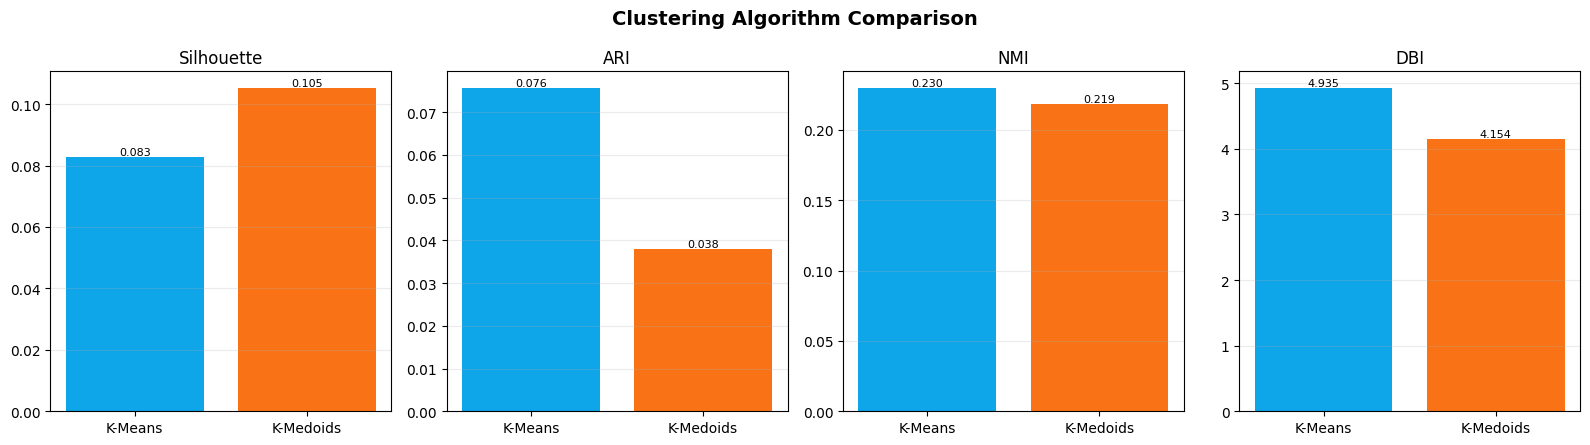

In [4]:
metric_order = [
    ("silhouette_score", "Silhouette"),
    ("adjusted_rand_index", "ARI"),
    ("normalized_mutual_info", "NMI"),
    ("davies_bouldin_index", "DBI"),
]

fig, axes = plt.subplots(1, len(metric_order), figsize=(16, 4.5))
for ax, (metric_key, label) in zip(axes, metric_order):
    values = [kmeans_metrics[metric_key], kmedoids_metrics[metric_key]]
    bars = ax.bar(["K-Means", "K-Medoids"], values, color=["#0ea5e9", "#f97316"])
    ax.set_title(label)
    ax.grid(axis="y", alpha=0.25)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Clustering Algorithm Comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(GRAPHS_DIR / "kmeans_kmedoids_comparison.png", dpi=180, bbox_inches="tight")
plt.show()